# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Mental Health Dataset](https://www.kaggle.com/datasets/jajidhasan/mental-health)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('mental_health.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Person_ID,Age,Gender,Occupation,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Physical_Activity,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
0,1,54,Male,Student,10.2,7.5,0,6.5,8,5.8,Low,6,2,0,1,1,1,1
1,2,44,Male,Student,6.8,4.5,0,5.1,4,7.9,High,2,1,1,0,0,0,0
2,3,30,Male,Employed,5.5,6.9,0,3.5,10,9.4,Low,2,0,1,1,1,0,1
3,4,58,Male,Employed,5.6,4.1,0,9.0,2,2.0,High,10,0,0,1,0,0,0
4,5,23,Female,Employed,10.1,6.0,1,3.8,4,4.6,Low,4,4,0,1,1,1,0


## last Five row

In [4]:
df.tail()

,Person_ID,Age,Gender,Occupation,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Physical_Activity,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
1995,1996,49,Female,Employed,4.8,4.0,1,8.0,1,9.8,Medium,5,0,1,1,1,0,0
1996,1997,33,Male,Employed,2.7,2.6,0,7.2,9,10.1,Low,8,1,1,1,1,1,1
1997,1998,28,Male,Employed,2.6,4.6,0,6.5,10,7.7,Medium,6,2,0,0,0,1,1
1998,1999,56,Female,Student,3.2,2.8,1,8.3,9,2.1,High,5,0,1,1,0,0,0
1999,2000,38,Male,Unemployed,7.8,7.6,0,7.2,7,9.6,Low,1,3,0,1,1,0,1


## Shape of our dataset

In [5]:
df.shape

(2000, 18)

## List out all columns

In [6]:
df.columns

Index(['Person_ID', 'Age', 'Gender', 'Occupation', 'Daily_Screen_Time',
       'Social_Media_Usage', 'Night_Usage', 'Sleep_Hours', 'Stress_Level',
       'Work_Study_Hours', 'Physical_Activity', 'Social_Interaction_Score',
       'Caffeine_Intake', 'Smoking', 'Alcohol', 'Depression', 'Anxiety',
       'Burnout'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Person_ID                     int64
Age                           int64
Gender                       object
Occupation                   object
Daily_Screen_Time           float64
Social_Media_Usage          float64
Night_Usage                   int64
Sleep_Hours                 float64
Stress_Level                  int64
Work_Study_Hours            float64
Physical_Activity            object
Social_Interaction_Score      int64
Caffeine_Intake               int64
Smoking                       int64
Alcohol                       int64
Depression                    int64
Anxiety                       int64
Burnout                       int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Person_ID                 2000 non-null   int64  
 1   Age                       2000 non-null   int64  
 2   Gender                    2000 non-null   object 
 3   Occupation                2000 non-null   object 
 4   Daily_Screen_Time         2000 non-null   float64
 5   Social_Media_Usage        2000 non-null   float64
 6   Night_Usage               2000 non-null   int64  
 7   Sleep_Hours               2000 non-null   float64
 8   Stress_Level              2000 non-null   int64  
 9   Work_Study_Hours          2000 non-null   float64
 10  Physical_Activity         2000 non-null   object 
 11  Social_Interaction_Score  2000 non-null   int64  
 12  Caffeine_Intake           2000 non-null   int64  
 13  Smoking                   2000 non-null   int64  
 14  Alcohol 

## Check Null Value

In [9]:
df.isnull().sum()

Person_ID                   0
Age                         0
Gender                      0
Occupation                  0
Daily_Screen_Time           0
Social_Media_Usage          0
Night_Usage                 0
Sleep_Hours                 0
Stress_Level                0
Work_Study_Hours            0
Physical_Activity           0
Social_Interaction_Score    0
Caffeine_Intake             0
Smoking                     0
Alcohol                     0
Depression                  0
Anxiety                     0
Burnout                     0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Person_ID,Age,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,37.694000,6.943150,4.436400,0.489500,6.00765,5.409500,7.005650,5.488000,2.029500,0.492000,0.513000,0.499000,0.505500,0.515500
std,577.494589,12.614195,2.882415,2.011725,0.500015,1.70631,2.885129,2.846442,2.885484,1.432709,0.500061,0.499956,0.500124,0.500095,0.499885
min,1.000000,16.000000,2.000000,1.000000,0.000000,3.00000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,500.750000,27.000000,4.500000,2.700000,0.000000,4.60000,3.000000,4.500000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1000.500000,38.000000,6.800000,4.400000,0.000000,6.00000,5.000000,7.100000,6.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000
75%,1500.250000,49.000000,9.400000,6.200000,1.000000,7.50000,8.000000,9.400000,8.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,2000.000000,59.000000,12.000000,8.000000,1.000000,9.00000,10.000000,12.000000,10.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

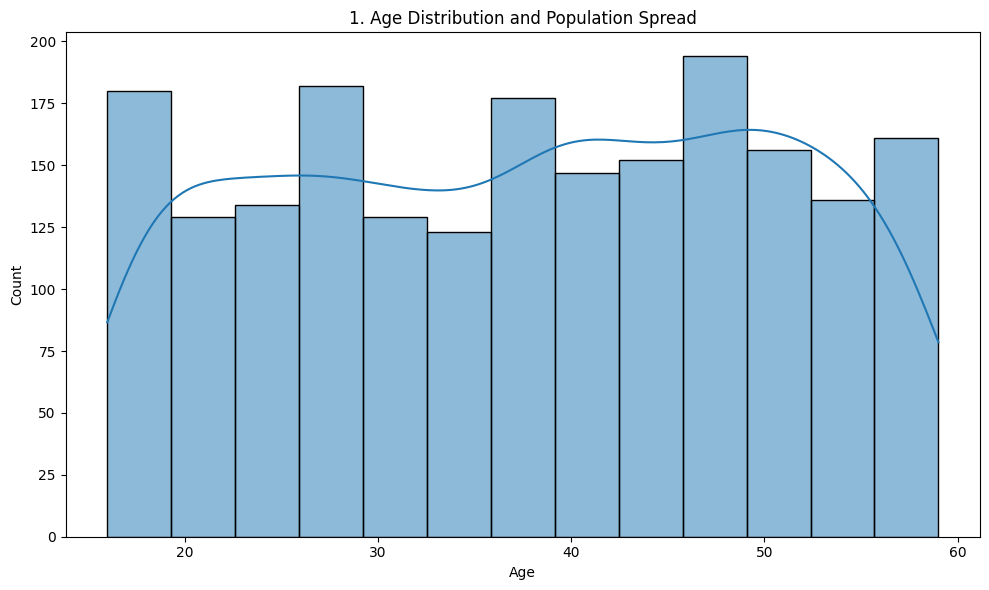

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Age'], kde=True)
plt.title(f'{plot_no}. Age Distribution and Population Spread')
show_fig()
plot_no += 1

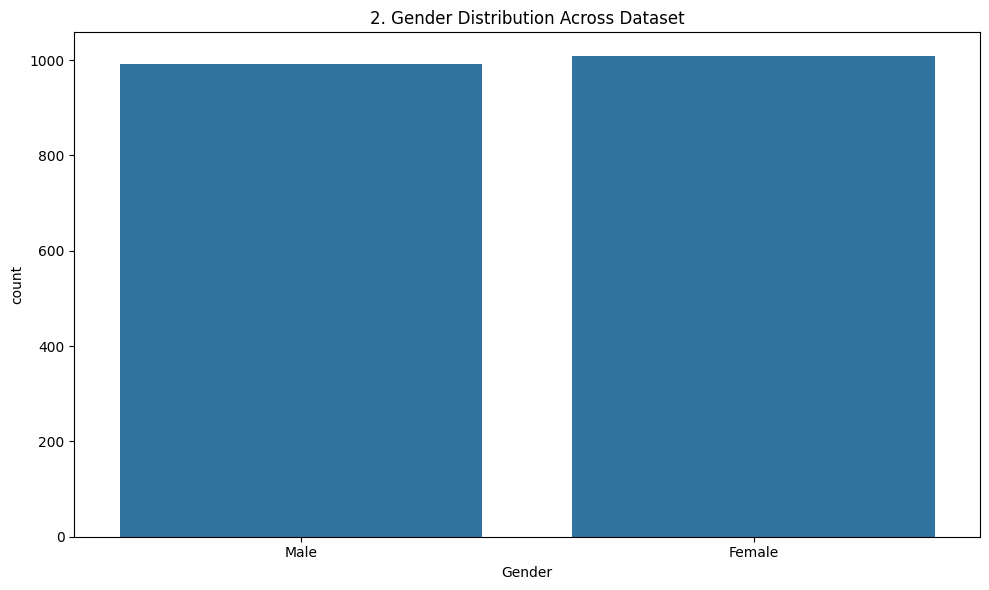

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Gender', data=df)
plt.title(f'{plot_no}. Gender Distribution Across Dataset')
show_fig()
plot_no += 1

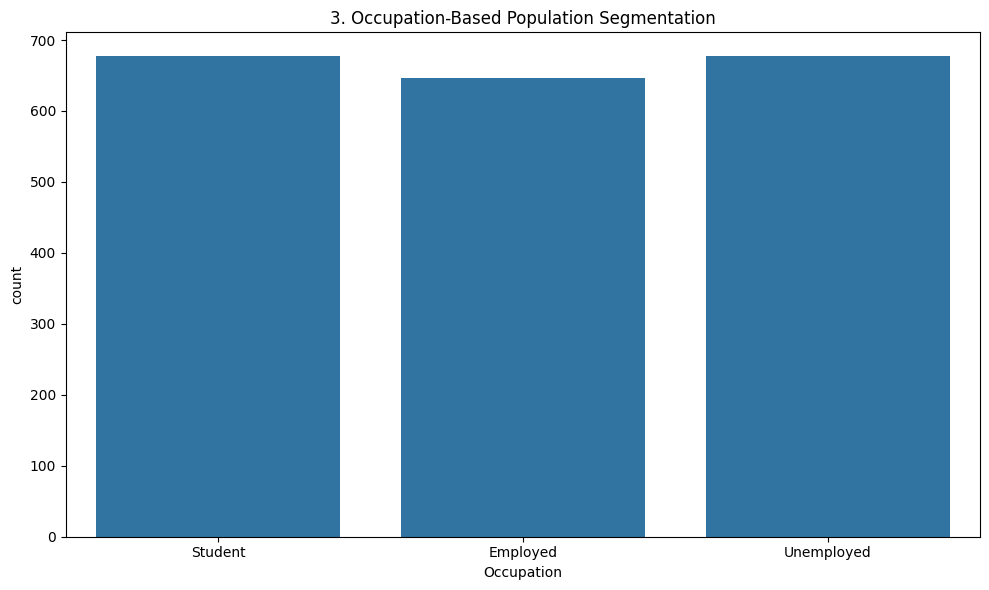

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Occupation', data=df)
plt.title(f'{plot_no}. Occupation-Based Population Segmentation')
show_fig()
plot_no += 1

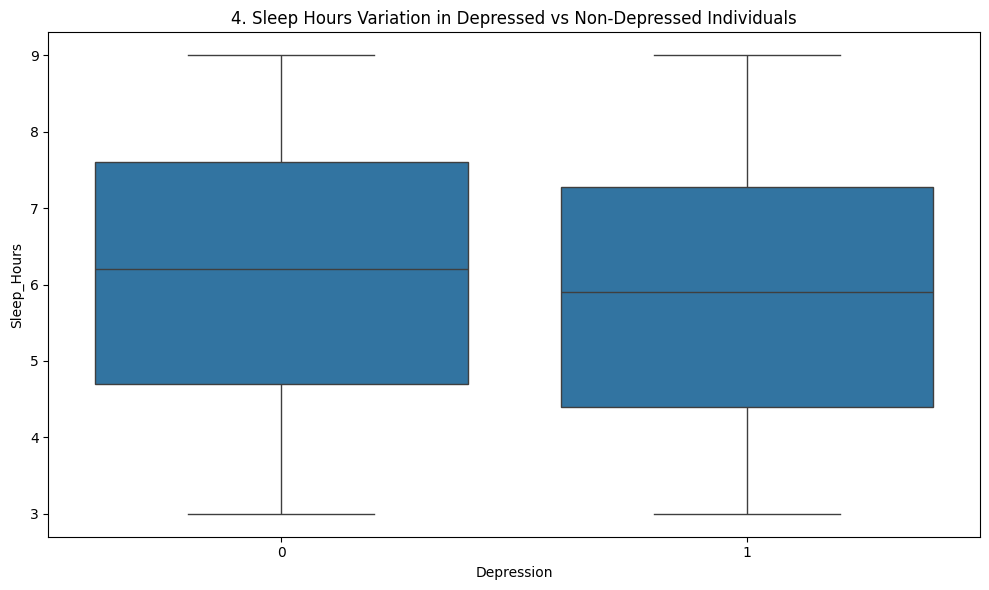

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Depression', y='Sleep_Hours', data=df)
plt.title(f'{plot_no}. Sleep Hours Variation in Depressed vs Non-Depressed Individuals')
show_fig()
plot_no += 1

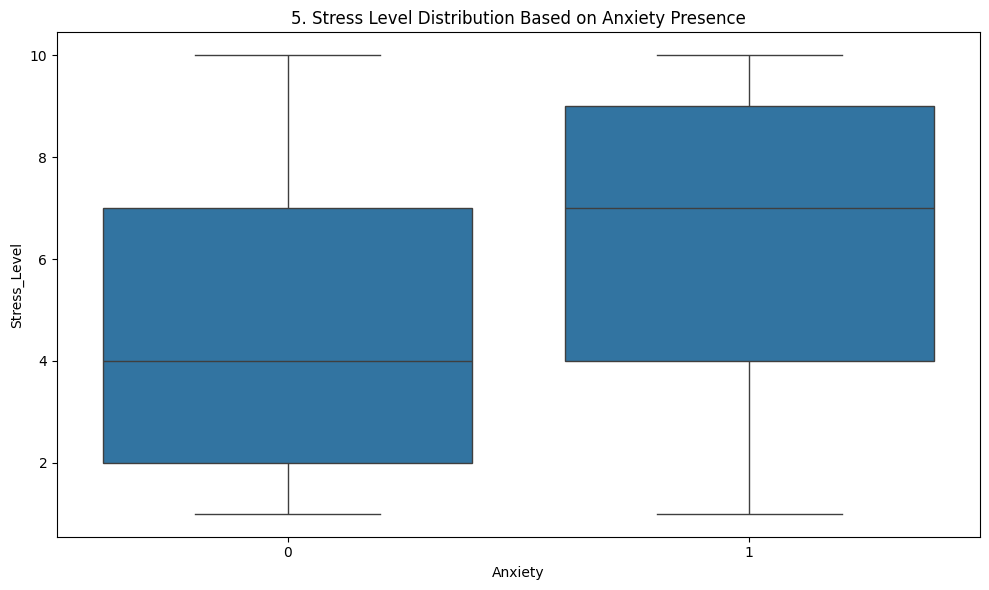

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Anxiety', y='Stress_Level', data=df)
plt.title(f'{plot_no}. Stress Level Distribution Based on Anxiety Presence')
show_fig()
plot_no += 1

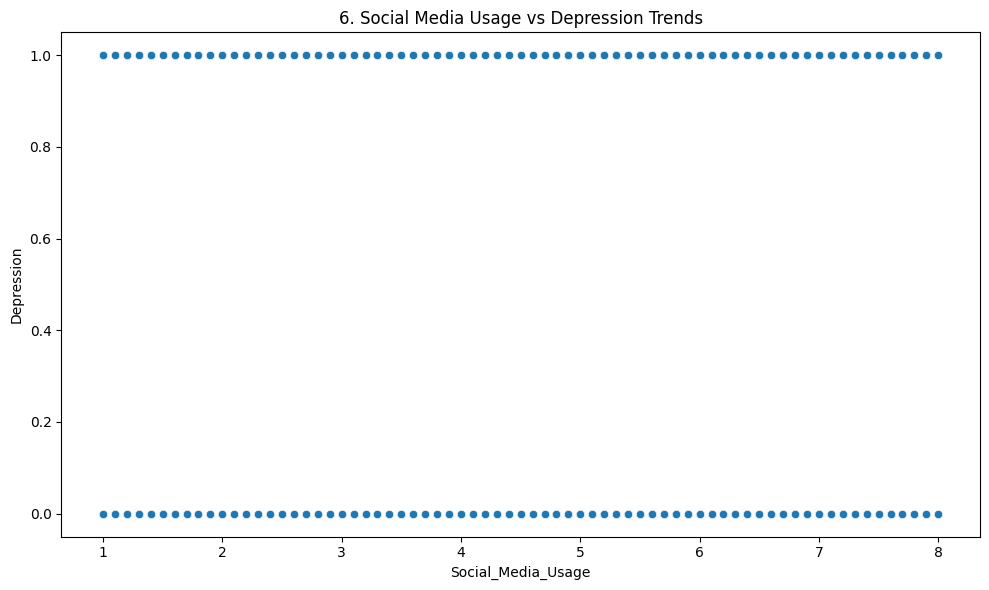

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Social_Media_Usage', y='Depression', data=df)
plt.title(f'{plot_no}. Social Media Usage vs Depression Trends')
show_fig()
plot_no += 1

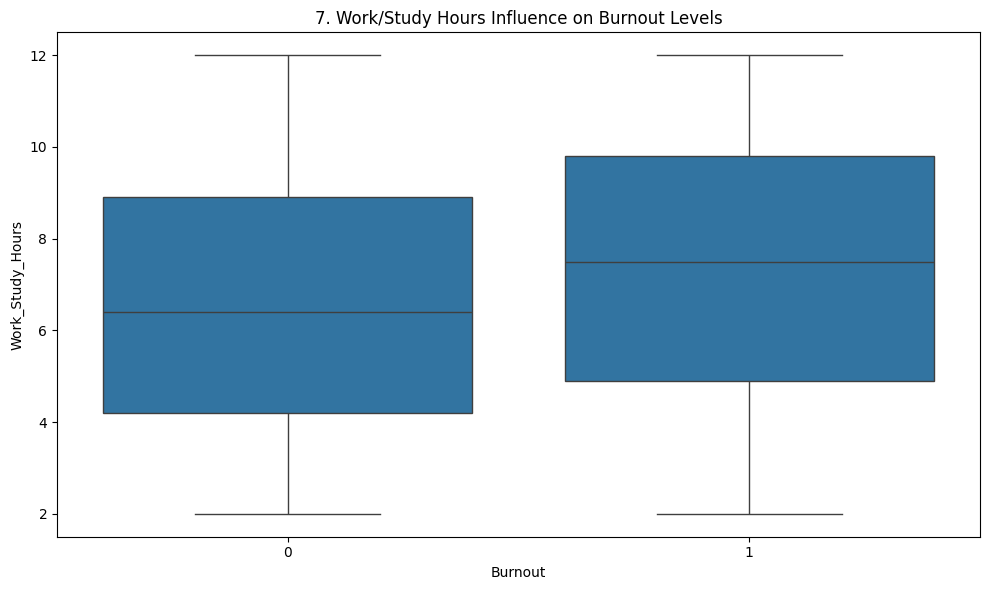

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Burnout', y='Work_Study_Hours', data=df)
plt.title(f'{plot_no}. Work/Study Hours Influence on Burnout Levels')
show_fig()
plot_no += 1

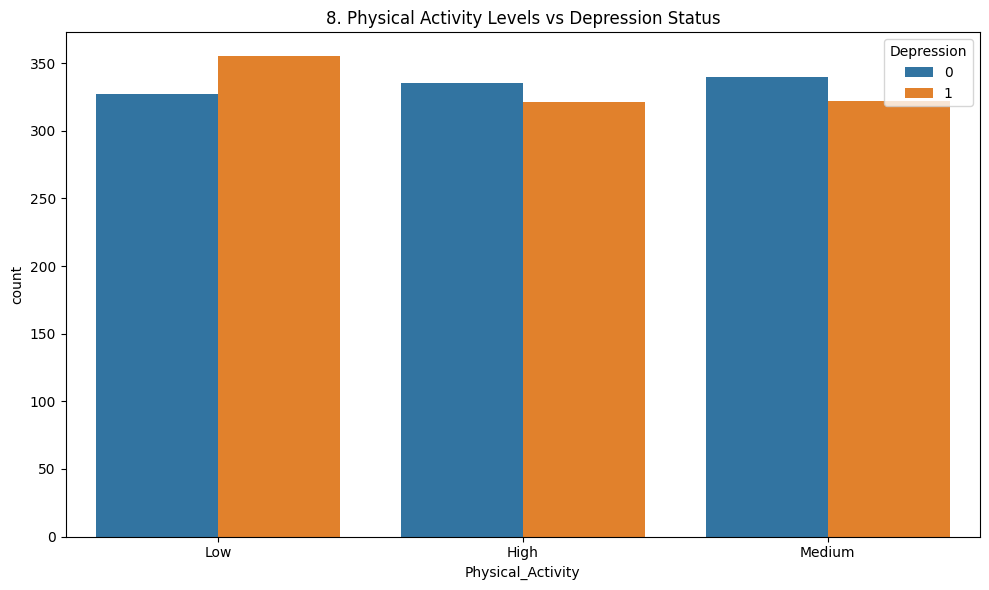

In [20]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Physical_Activity', hue='Depression', data=df)
plt.title(f'{plot_no}. Physical Activity Levels vs Depression Status')
show_fig()
plot_no += 1

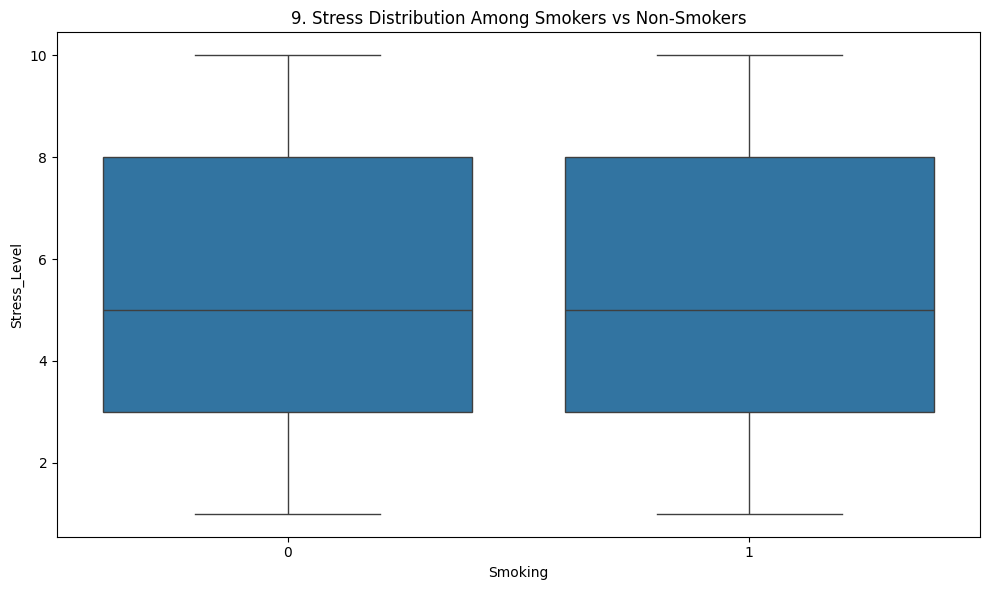

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Smoking', y='Stress_Level', data=df)
plt.title(f'{plot_no}. Stress Distribution Among Smokers vs Non-Smokers')
show_fig()
plot_no += 1

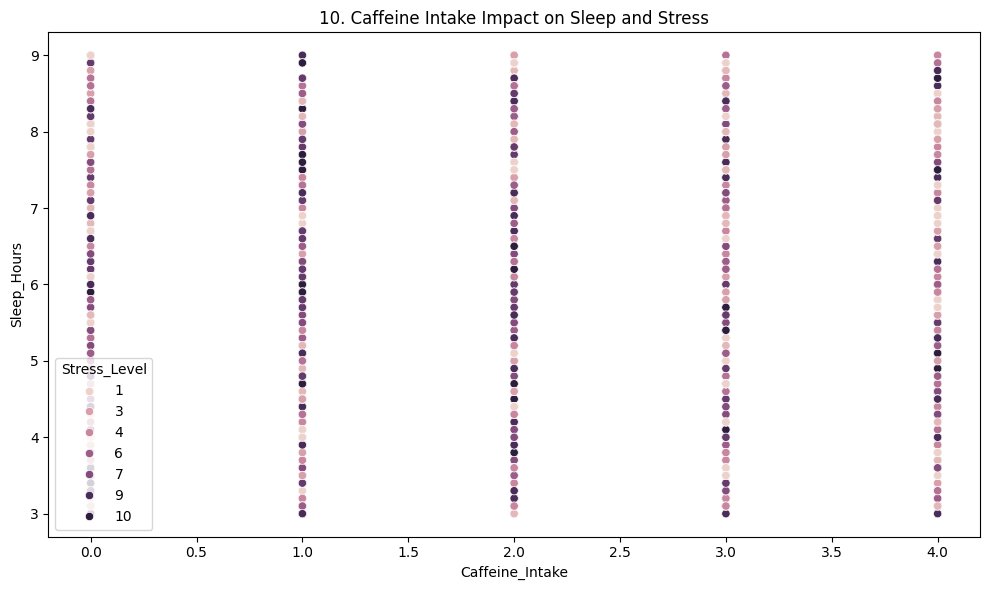

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Caffeine_Intake', y='Sleep_Hours', hue='Stress_Level', data=df)
plt.title(f'{plot_no}. Caffeine Intake Impact on Sleep and Stress')
show_fig()
plot_no += 1

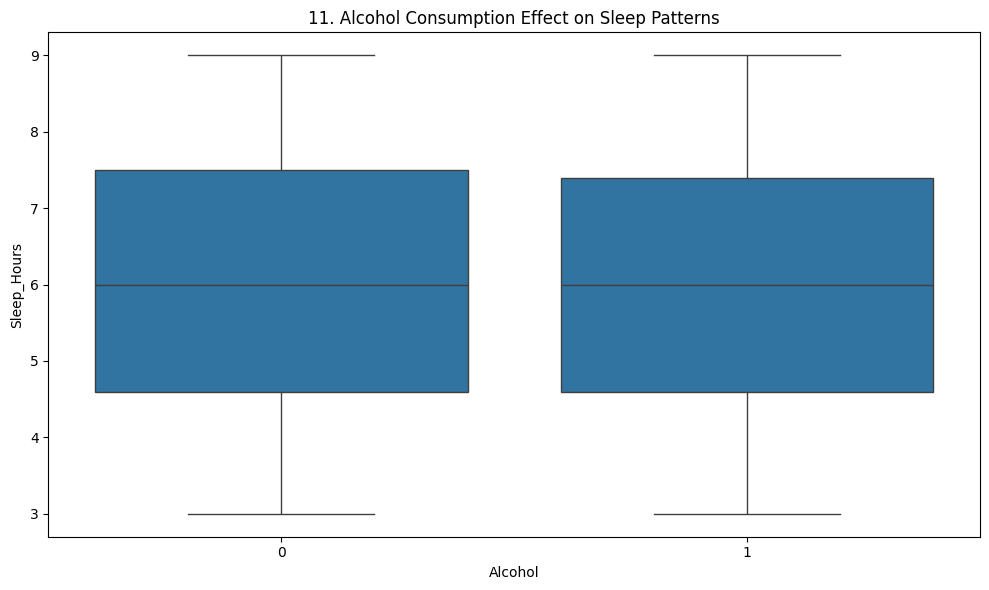

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Alcohol', y='Sleep_Hours', data=df)
plt.title(f'{plot_no}. Alcohol Consumption Effect on Sleep Patterns')
show_fig()
plot_no += 1

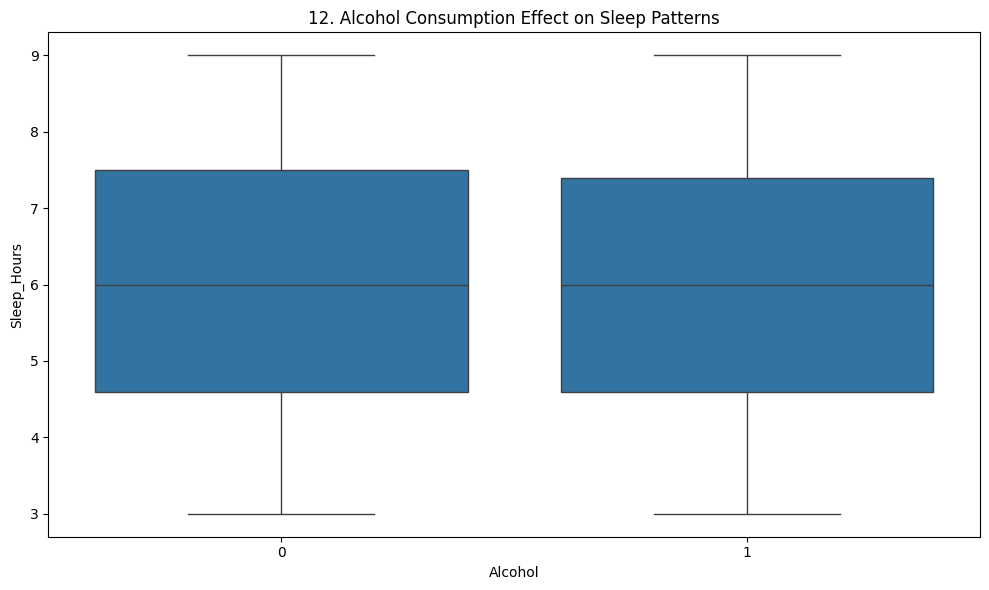

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Alcohol', y='Sleep_Hours', data=df)
plt.title(f'{plot_no}. Alcohol Consumption Effect on Sleep Patterns')
show_fig()
plot_no += 1

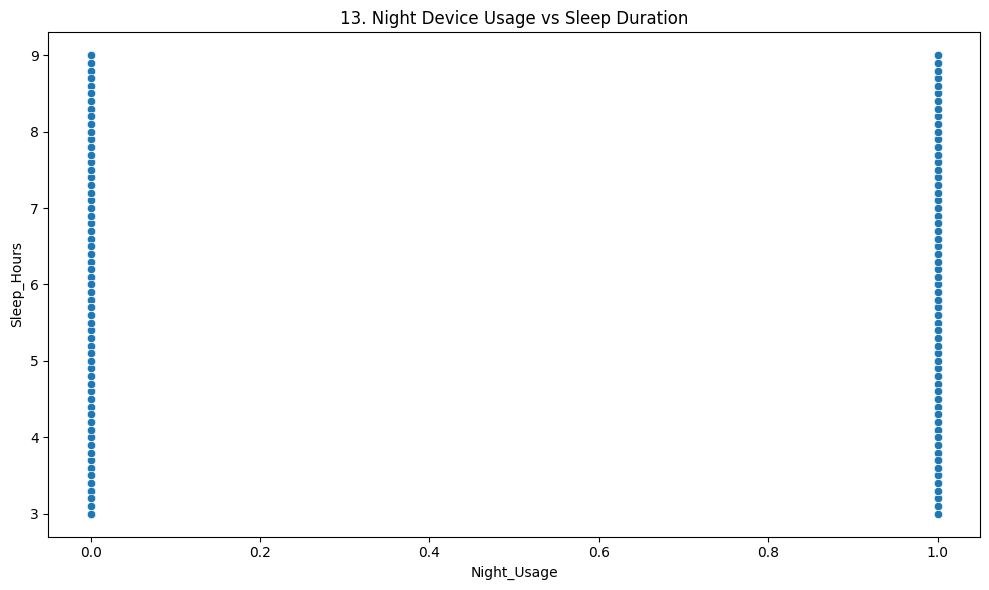

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Night_Usage', y='Sleep_Hours', data=df)
plt.title(f'{plot_no}. Night Device Usage vs Sleep Duration')
show_fig()
plot_no += 1

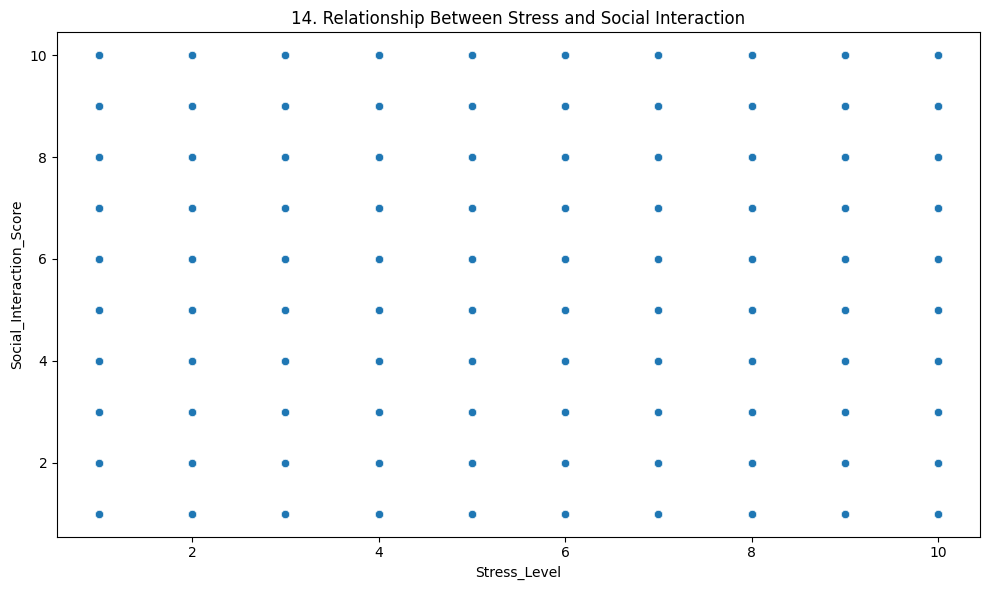

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Stress_Level', y='Social_Interaction_Score', data=df)
plt.title(f'{plot_no}. Relationship Between Stress and Social Interaction')
show_fig()
plot_no += 1

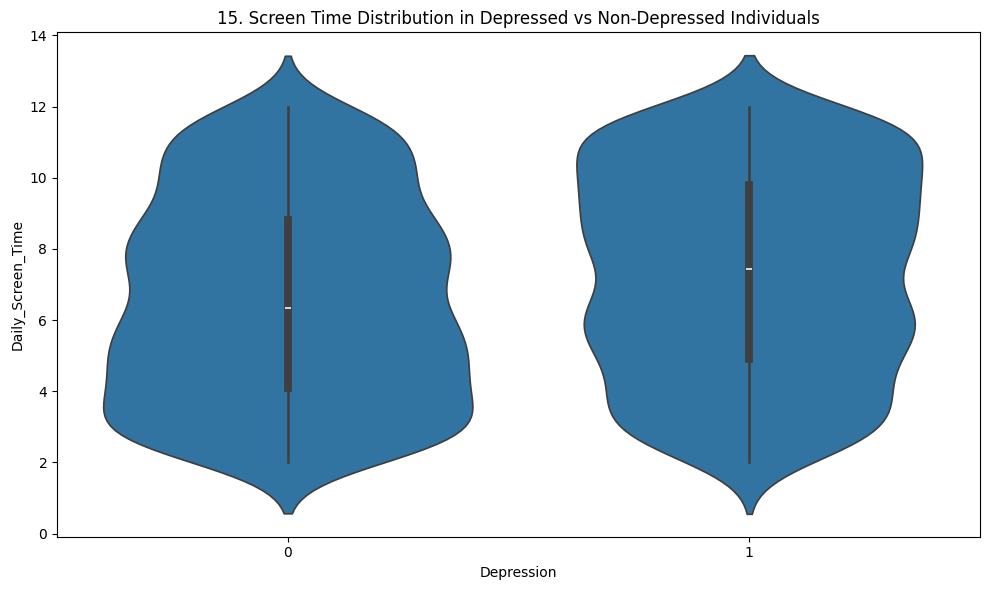

In [27]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='Depression', y='Daily_Screen_Time', data=df)
plt.title(f'{plot_no}. Screen Time Distribution in Depressed vs Non-Depressed Individuals')
show_fig()
plot_no += 1

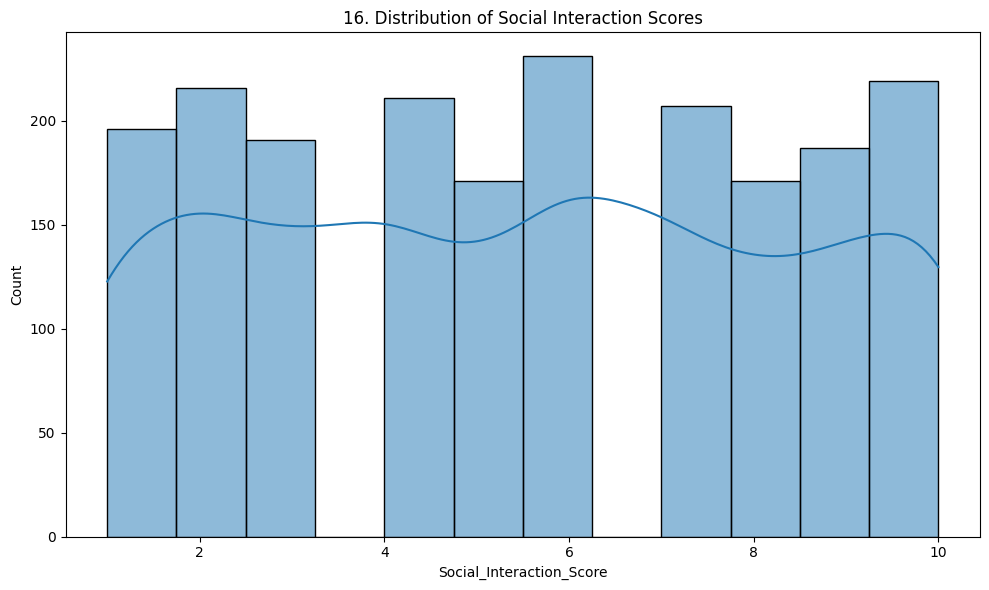

In [28]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Social_Interaction_Score'], kde=True)
plt.title(f'{plot_no}. Distribution of Social Interaction Scores')
show_fig()
plot_no += 1

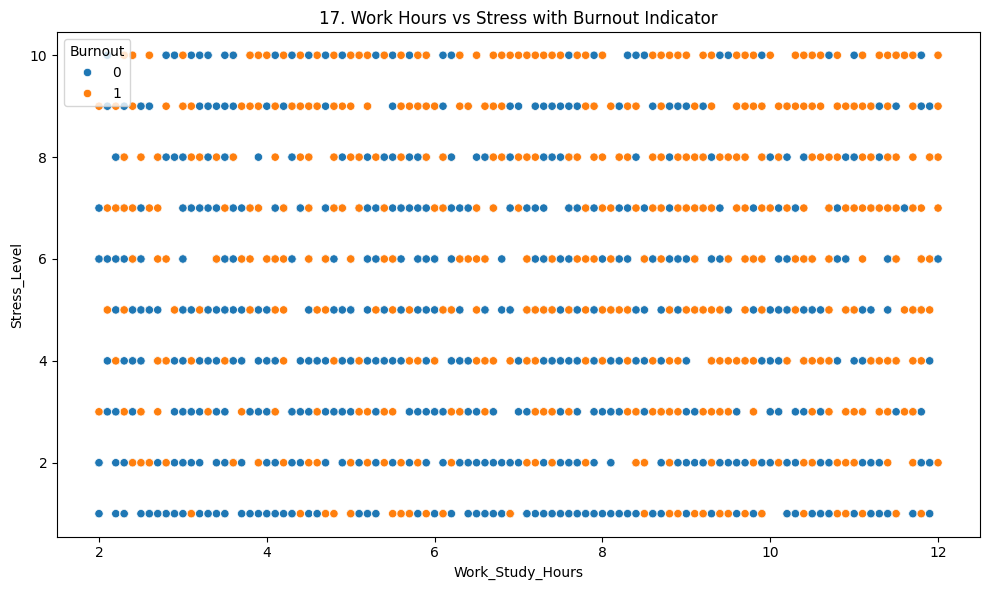

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Work_Study_Hours', y='Stress_Level', hue='Burnout', data=df)
plt.title(f'{plot_no}. Work Hours vs Stress with Burnout Indicator')
show_fig()
plot_no += 1

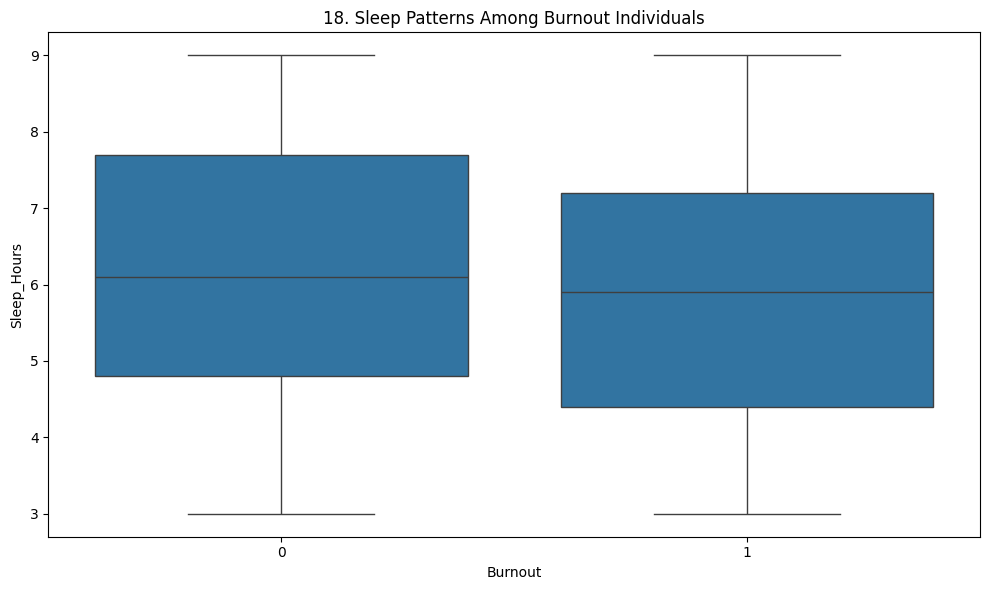

In [30]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Burnout', y='Sleep_Hours', data=df)
plt.title(f'{plot_no}. Sleep Patterns Among Burnout Individuals')
show_fig()
plot_no += 1

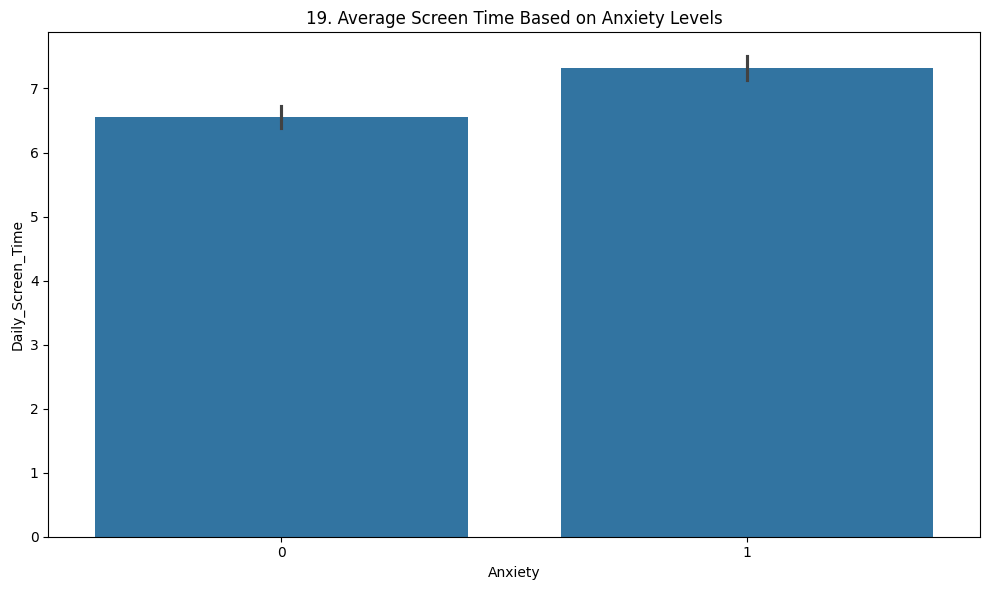

In [31]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='Anxiety', y='Daily_Screen_Time', data=df)
plt.title(f'{plot_no}. Average Screen Time Based on Anxiety Levels')
show_fig()
plot_no += 1

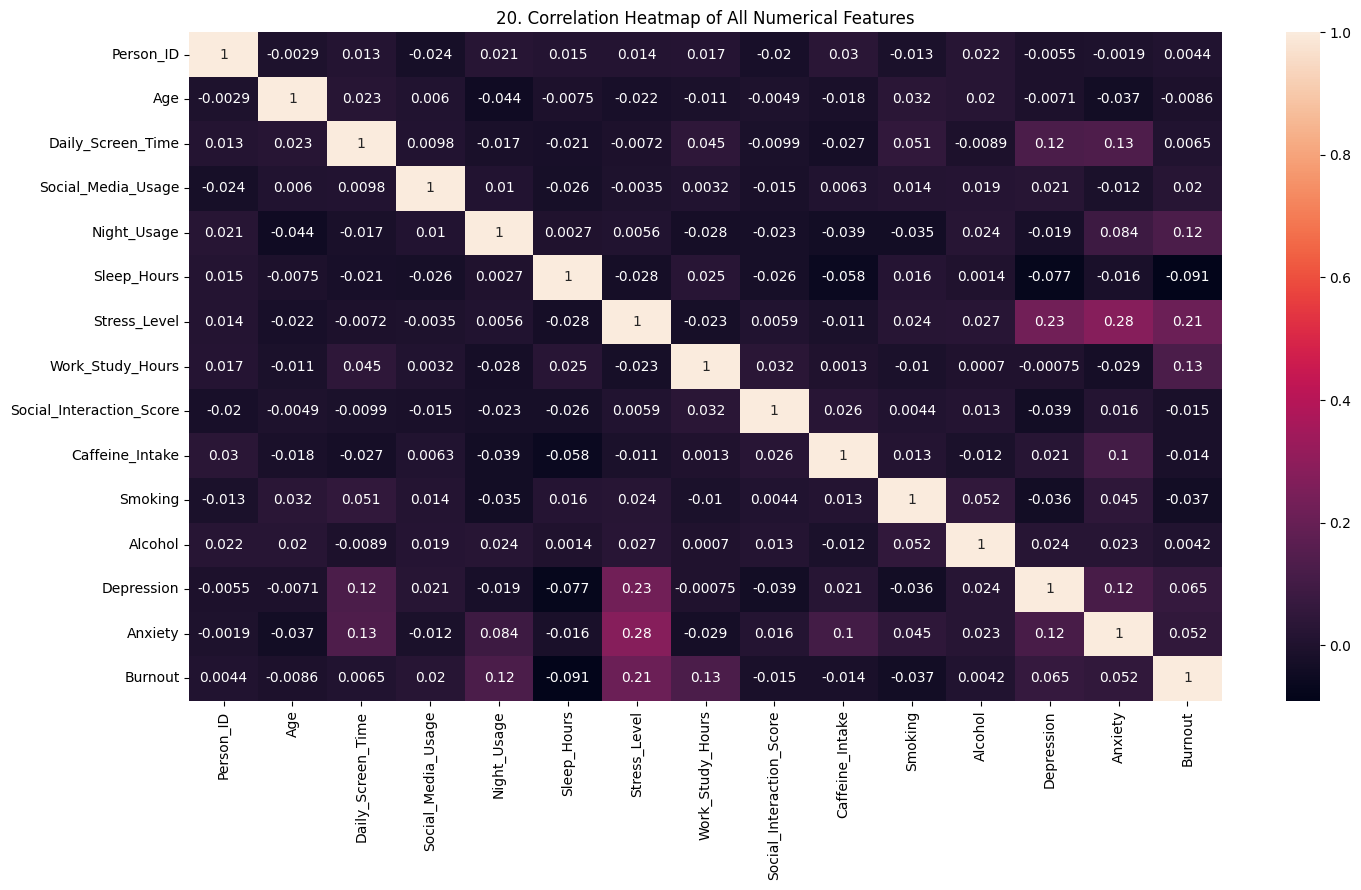

In [32]:
fig = plt.figure(figsize=(15, 9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of All Numerical Features')
show_fig()
plot_no += 1

# Model Training

## define features and target

In [33]:
X = df.drop(columns=['Depression'])
y = df['Depression']

## convert categorical columns to numeric

In [34]:
X = pd.get_dummies(X, drop_first=True)

## split the dataset

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## apply feature scaling

In [36]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train SVM model

In [37]:
model = SVC(kernel='rbf')
model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## make predictions

In [38]:
y_pred = model.predict(X_test)

## calculate accuracy

In [39]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.61


## plot confusion matrix

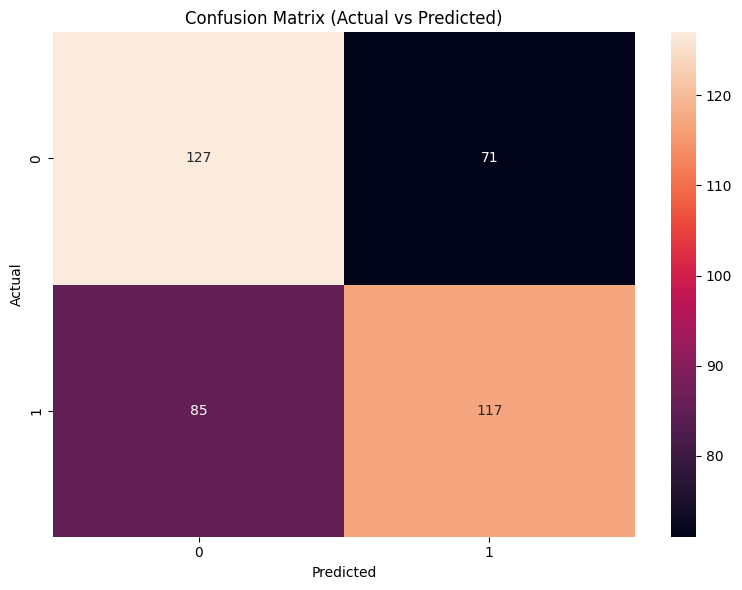

In [40]:
fig = plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix (Actual vs Predicted)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()